Original Shape: (5, 21)
After cleaning: (5, 21)
After label filter: (5, 21)


/tmp/ipykernel_4376/1608775906.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('...', np.nan, inplace=True)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


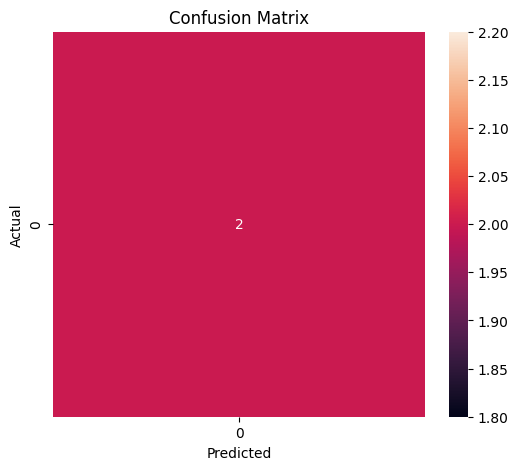

In [8]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# LOAD DATASET
# ===============================
df = pd.read_csv('/content/MHEALTHDATASET.csv')

print("Original Shape:", df.shape)

# ===============================
# FIX STRING VALUES (VERY SAFE)
# ===============================

# Replace '...' with NaN
df.replace('...', np.nan, inplace=True)

# Fill NaN instead of dropping rows
df = df.fillna(df.mean(numeric_only=True))

print("After cleaning:", df.shape)

# ===============================
# CHECK TARGET COLUMN
# ===============================
if 'label' not in df.columns:
    raise Exception("❌ 'label' column not found")

# ===============================
# REMOVE LABEL 0 ONLY IF SAFE
# ===============================
if df['label'].nunique() > 1:
    df = df[df['label'] != 0]

print("After label filter:", df.shape)

# ===============================
# FINAL SAFETY CHECK
# ===============================
if df.shape[0] == 0:
    raise Exception("❌ Dataset became empty. Do NOT filter data.")

# ===============================
# FEATURES & TARGET
# ===============================
X = df.drop('label', axis=1)
y = df['label']

# ===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ===============================
# MODEL (NO SCALING NEEDED)
# ===============================
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# ===============================
# PREDICTION
# ===============================
y_pred = model.predict(X_test)

# ===============================
# RESULTS
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()